Data loaded successfully
Shape: (1001, 7)
   order_id customer_id sales_person  priority ship_mode       date  value_£
0      8999        C406        Kelly      High     Plane 2020-06-12  1553.44
1     47872        C100        Kelly  Critical     Plane 2020-06-12   315.40
2     29988        C006        Kelly      High     Lorry 2020-06-12  5075.89
3     37348        C492        Kelly      High     Plane 2020-06-13   520.67
4     28001        C231        Kelly  Critical     Plane 2020-06-14  8431.37
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      1001 non-null   int64         
 1   customer_id   1001 non-null   object        
 2   sales_person  1001 non-null   object        
 3   priority      1001 non-null   object        
 4   ship_mode     1001 non-null   object        
 5   date          1001 non-null   datet

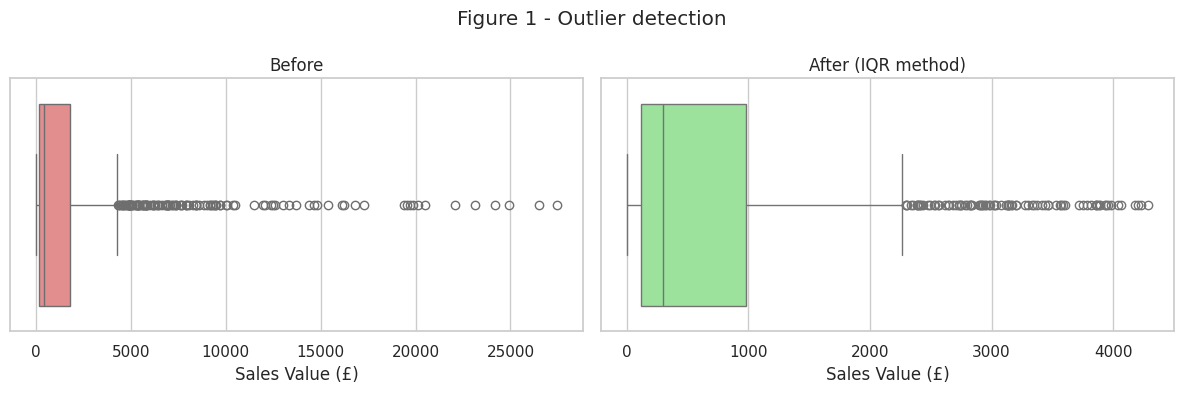

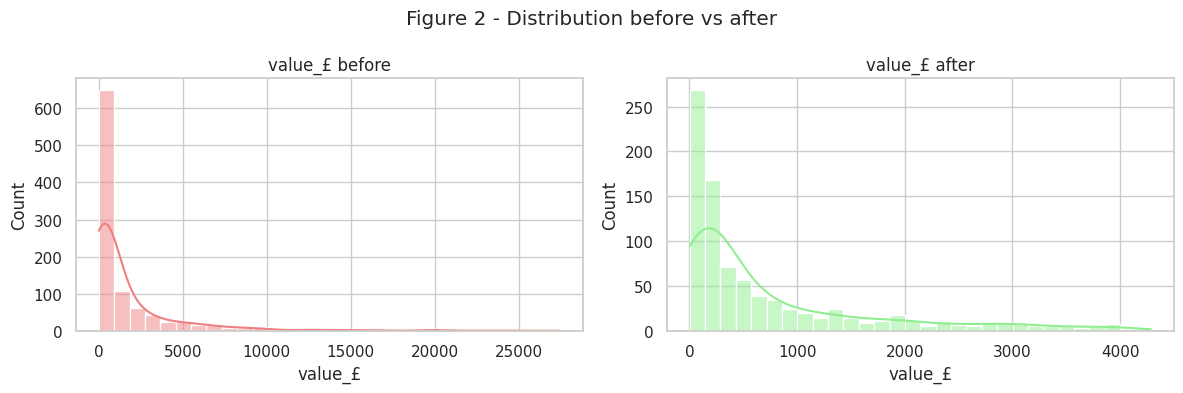

Skewness after: 1.76

Before vs After:
         Before    After
count   1001.00   879.00
mean    1778.40   747.30
std     3457.46   961.98
min        2.45     2.45
25%      134.40   113.34
50%      417.58   297.97
75%     1816.93   981.96
max    27448.24  4286.74

Sales person summary:
                  Total     Avg  Count      Max
sales_person                                   
Pryia         229755.92  795.00    289  4227.02
Kelly         226801.95  804.26    282  4286.74
Peter         200322.99  650.40    308  4182.90


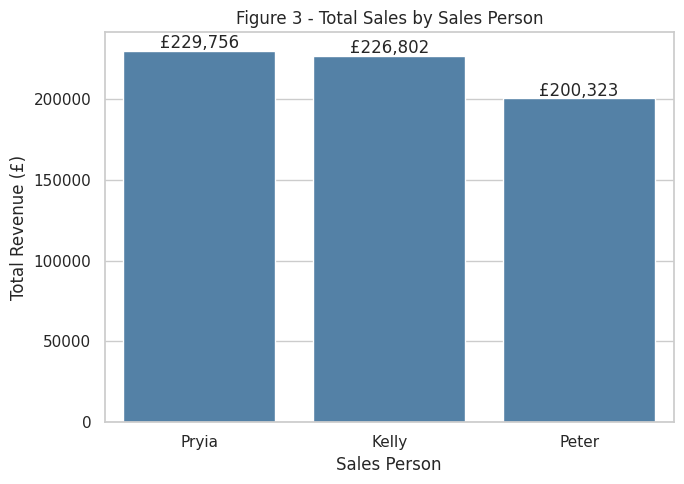

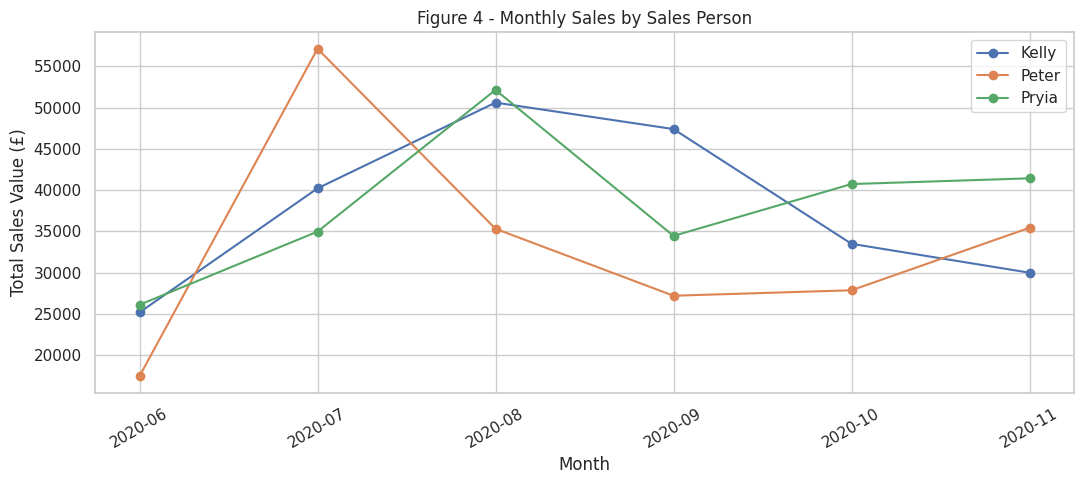


Monthly totals:
sales_person     Kelly     Peter     Pryia
Month                                     
2020-06       25161.36  17434.47  26091.26
2020-07       40201.15  57126.53  34955.11
2020-08       50595.81  35301.35  52133.18
2020-09       47386.50  27186.89  34438.48
2020-10       33478.73  27848.67  40721.38
2020-11       29978.40  35425.08  41416.51

Rows used for correlation: 691

Spearman r = 0.0461  p = 0.2258
Pearson  r = 0.0463  p = 0.2242
No significant correlation (p >= 0.05)

Stats by priority level:
            mean  median  count
priority                       
Low       687.97  274.62    182
Medium    834.97  342.23    150
High      733.17  343.79    167
Critical  847.26  298.42    192


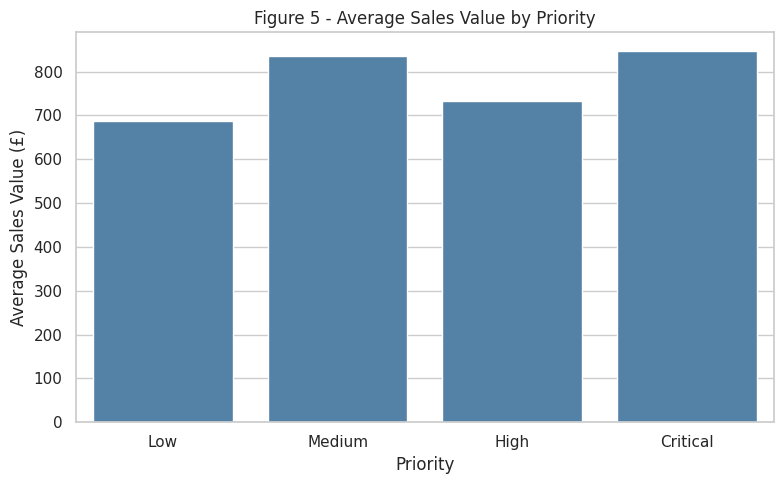

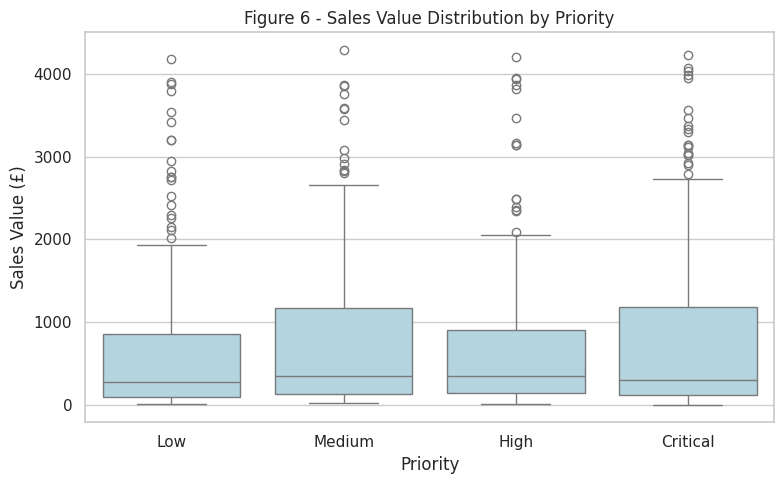


Revenue by shipping mode:
               Total  Count      Avg
ship_mode                           
Plane      435939.99    708   615.73
Lorry      137453.28     74  1857.48
Van         83487.59     97   860.70


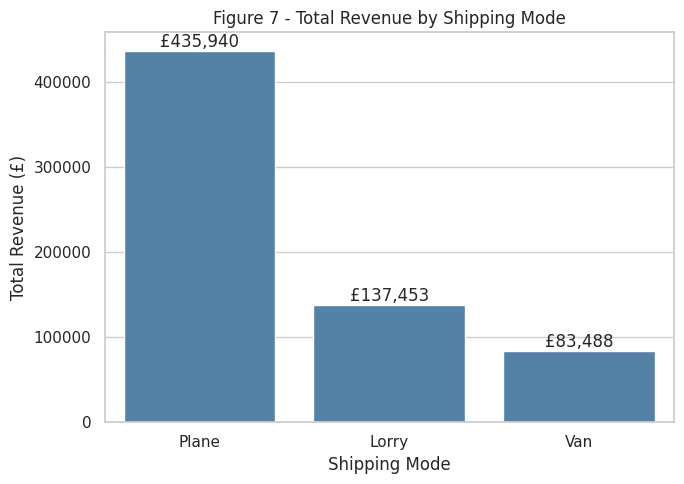


Saved cleaned data. Final shape: (879, 8)


In [ ]:
# Programming for Data Analytics - COM 7024
# Student ID: 25238053
# Dataset: Sales Data_PDA_4052.xlsx
# Target: Sales Data Analysis - One Time Sales and Marketing Ltd.

# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

# Loading Dataset - Sales Data_PDA_4052.xlsx
# The first row of the sheet is a title, so skip it
df = pd.read_excel('/content/Sales Data_PDA_4052.xlsx', skiprows=1)
df.columns = df.columns.str.strip()
print("Data loaded successfully")

print("Shape:", df.shape)
print(df.head())
print(df.info())

# Converting date column to proper datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Checking for any duplicate rows
print("\nDuplicated rows:", df.duplicated().sum())

# Now checking missing values per column
print("\nNulls per column:")
print(df.isnull().sum())

# Looking at unique values in categorical columns
print("\nPriority counts:")
print(df['priority'].value_counts())

# Same check for ship mode
print("\nShip mode counts:")
print(df['ship_mode'].value_counts())

# And for sales person
print("\nSales person counts:")
print(df['sales_person'].value_counts())

# Initial statistical overview (before preprocessing)
print("\nDescribe value_£ (raw):")
print(df['value_£'].describe())
print("Skewness:", round(df['value_£'].skew(), 2))

# 'Not Specified' in priority is basically a missing value, so replacing it with NaN
df['priority'] = df['priority'].replace('Not Specified', np.nan)
print("\nNulls after fixing priority:")
print(df.isnull().sum())

# Now detecting and handling outliers (especially value_£)
# Using the Interquartile Range (IQR) method
Q1 = df['value_£'].quantile(0.25)
Q3 = df['value_£'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("\nQ1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower bound:", round(lower, 2))
print("Upper bound:", round(upper, 2))

df_clean = df[(df['value_£'] >= lower) & (df['value_£'] <= upper)].copy()

print("\nBefore:", len(df), "rows")
print("After:", len(df_clean), "rows")
print("Outliers removed:", len(df) - len(df_clean))

# Boxplots before vs after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['value_£'], ax=axes[0], color='lightcoral')
axes[0].set_title('Before')
axes[0].set_xlabel('Sales Value (£)')
sns.boxplot(x=df_clean['value_£'], ax=axes[1], color='lightgreen')
axes[1].set_title('After (IQR method)')
axes[1].set_xlabel('Sales Value (£)')
plt.suptitle('Figure 1 - Outlier detection')
plt.tight_layout()
plt.show()

# Histograms before vs after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['value_£'], bins=30, ax=axes[0], color='lightcoral', kde=True)
axes[0].set_title('value_£ before')
sns.histplot(df_clean['value_£'], bins=30, ax=axes[1], color='lightgreen', kde=True)
axes[1].set_title('value_£ after')
plt.suptitle('Figure 2 - Distribution before vs after')
plt.tight_layout()
plt.show()

# Comparing value_£ stats (before vs after)
print("Skewness after:", round(df_clean['value_£'].skew(), 2))

compare = pd.DataFrame({
    'Before': df['value_£'].describe(),
    'After': df_clean['value_£'].describe()
}).round(2)
print("\nBefore vs After:")
print(compare)

# Adding a Month column for time-based analysis
df_clean['Month'] = df_clean['date'].dt.to_period('M')

# Summary stats per sales person
summary = df_clean.groupby('sales_person')['value_£'].agg(
    Total='sum',
    Avg='mean',
    Count='count',
    Max='max'
).round(2).sort_values('Total', ascending=False)

print("\nSales person summary:")
print(summary)

# Bar chart - total sales per sales person
totals = df_clean.groupby('sales_person')['value_£'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=totals.index, y=totals.values, color='steelblue')
plt.title('Figure 3 - Total Sales by Sales Person')
plt.xlabel('Sales Person')
plt.ylabel('Total Revenue (£)')
for i, v in enumerate(totals.values):
    plt.text(i, v + 1500, f"£{v:,.0f}", ha='center')
plt.tight_layout()
plt.show()

# Line chart - monthly sales by sales person
monthly = df_clean.groupby(['Month', 'sales_person'])['value_£'].sum().unstack(fill_value=0)

plt.figure(figsize=(11, 5))
for person in monthly.columns:
    plt.plot(monthly.index.astype(str), monthly[person], marker='o', label=person)
plt.title('Figure 4 - Monthly Sales by Sales Person')
plt.xlabel('Month')
plt.ylabel('Total Sales Value (£)')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

print("\nMonthly totals:")
print(monthly.round(2))

# Moving on to correlation between priority and value_£
# First dropping rows where priority is missing
df_corr = df_clean.dropna(subset=['priority']).copy()
print("\nRows used for correlation:", len(df_corr))

# Mapping priority to numeric (ordinal scale: Low=1, Medium=2, High=3, Critical=4)
pmap = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df_corr['priority_num'] = df_corr['priority'].map(pmap)

# Spearman correlation since priority is ordinal, not continuous
sp_r, sp_p = stats.spearmanr(df_corr['priority_num'], df_corr['value_£'])
# Pearson is added for comparison only
pe_r, pe_p = stats.pearsonr(df_corr['priority_num'], df_corr['value_£'])

print("\nSpearman r =", round(sp_r, 4), " p =", round(sp_p, 4))
print("Pearson  r =", round(pe_r, 4), " p =", round(pe_p, 4))

# Checking if the correlation is significant
if sp_p < 0.05:
    print("Significant correlation (p < 0.05)")
else:
    print("No significant correlation (p >= 0.05)")

# Mean / median sales value per priority level
by_priority = df_corr.groupby('priority')['value_£'].agg(['mean', 'median', 'count']).round(2)
by_priority = by_priority.reindex(['Low', 'Medium', 'High', 'Critical'])
print("\nStats by priority level:")
print(by_priority)

# Bar chart - average value per priority
order = ['Low', 'Medium', 'High', 'Critical']
plt.figure(figsize=(8, 5))
sns.barplot(x='priority', y='value_£', data=df_corr, order=order,
            color='steelblue', errorbar=None)
plt.title('Figure 5 - Average Sales Value by Priority')
plt.xlabel('Priority')
plt.ylabel('Average Sales Value (£)')
plt.tight_layout()
plt.show()

# Boxplot to see the spread per priority
plt.figure(figsize=(8, 5))
sns.boxplot(x='priority', y='value_£', data=df_corr, order=order, color='lightblue')
plt.title('Figure 6 - Sales Value Distribution by Priority')
plt.xlabel('Priority')
plt.ylabel('Sales Value (£)')
plt.tight_layout()
plt.show()

# Extra check - revenue by shipping mode
ship = df_clean.groupby('ship_mode')['value_£'].agg(
    Total='sum', Count='count', Avg='mean'
).round(2).sort_values('Total', ascending=False)

print("\nRevenue by shipping mode:")
print(ship)

# Bar chart - total revenue per shipping mode
plt.figure(figsize=(7, 5))
sns.barplot(x=ship.index, y=ship['Total'], color='steelblue')
plt.title('Figure 7 - Total Revenue by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Total Revenue (£)')
for i, v in enumerate(ship['Total']):
    plt.text(i, v + 5000, f"£{v:,.0f}", ha='center')
plt.tight_layout()
plt.show()

# Saving cleaned data
df_clean.to_csv('sales_data_cleaned.csv', index=False)
print("\nSaved cleaned data. Final shape:", df_clean.shape)